In [1]:
!pip uninstall -y transformers tokenizers protobuf
!pip install --no-cache-dir transformers==4.38.2 tokenizers==0.15.2 protobuf==3.20.3

Found existing installation: transformers 4.53.3
Uninstalling transformers-4.53.3:
  Successfully uninstalled transformers-4.53.3
Found existing installation: tokenizers 0.21.2
Uninstalling tokenizers-0.21.2:
  Successfully uninstalled tokenizers-0.21.2
Found existing installation: protobuf 6.33.0
Uninstalling protobuf-6.33.0:
  Successfully uninstalled protobuf-6.33.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 88.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 275.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 343.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requ

In [2]:
from transformers import AutoTokenizer, AutoModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "seyonec/ChemBERTa-zinc-base-v1"

chem_tokenizer = AutoTokenizer.from_pretrained(model_name)
chem_model = AutoModel.from_pretrained(model_name).to(device)

print("ChemBERTa 로드 성공")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/179M [00:00<?, ?B/s]

ChemBERTa 로드 성공


In [3]:
import pandas as pd 

df = pd.read_csv('/kaggle/input/cano-smiles/after_preprocessing.csv')
df = df[df['scaffold'] != df['smiles']]
df = df[~ df['scaffold'].isnull()]
df = df.reset_index(drop=True)
df.shape

(761562, 2)

In [4]:
# scaffold 컬럼이 문자열이라고 가정
lengths = df['scaffold'].astype(str).str.len()

print(lengths.describe())

count    761562.000000
mean         34.218623
std           8.698273
min           5.000000
25%          29.000000
50%          35.000000
75%          40.000000
max          66.000000
Name: scaffold, dtype: float64


In [5]:
# scaffold 컬럼이 문자열이라고 가정
lengths = df['smiles'].astype(str).str.len()

print(lengths.describe())

count    761562.000000
mean         46.220355
std           5.770148
min          31.000000
25%          41.000000
50%          46.000000
75%          51.000000
max          76.000000
Name: smiles, dtype: float64


In [6]:
PAD = chem_tokenizer.pad_token_id
BOS = chem_tokenizer.cls_token_id
EOS = chem_tokenizer.sep_token_id
VOCAB_SIZE = chem_tokenizer.vocab_size

In [7]:
import numpy as np
from collections import defaultdict

def scaffold_stratified_split(df, scaffold_col='scaffold', val_ratio=0.2, seed=100):
	np.random.seed(seed)

	scaffold_to_indices = defaultdict(list)
	# 형태 : {'scaffold 분자식' : [scaffold의 index]}
	# = scaffold별 인덱스 모으기

	for idx, scaf in enumerate(df[scaffold_col]):
		scaffold_to_indices[scaf].append(idx)

	scaffolds = list(scaffold_to_indices.keys())
	np.random.shuffle(scaffolds)

	train_indices, val_indices = [], []

	# train과 valid 사이에 scaffold 중복이 절대 없게 함
	# = 과적합을 줄이고 학습하지 않은 새로운 분자 예측을 올바르게 수행하기 위해서 
	val_target = int(len(df) * val_ratio) # 약 16만개
	val_count = 0

	for scaf in scaffolds:
		indices = scaffold_to_indices[scaf] # 인덱스 리스트
		if val_count < val_target: # 만약 약 16만개의 valid 데이터셋이 다 채워지지 않았다면
			val_indices.extend(indices) # 해당 scaffold는 전부 validation set
			val_count += len(indices) 
		else:
			train_indices.extend(indices) # 남은건 전부 train dataset

	train_df = df.iloc[train_indices].reset_index(drop=True)
	val_df = df.iloc[val_indices].reset_index(drop=True)
	
	return train_df, val_df

train_df, val_df = scaffold_stratified_split(df)

train_df.shape, val_df.shape

((609249, 2), (152313, 2))

In [8]:
train_sample = train_df.reset_index()
validation_sample = val_df.reset_index()

In [9]:
def dataset_encoding_fast(df, tokenizer, max_length=128):
    scaffolds = df["scaffold"].astype(str).tolist()
    smiles = df["smiles"].astype(str).tolist()

    scaffold_enc = tokenizer(
        scaffolds,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        add_special_tokens=True,
        return_tensors="pt"
    )["input_ids"]

    smiles_enc = tokenizer(
        smiles,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        add_special_tokens=True,
        return_tensors="pt"
    )["input_ids"]

    encoded_list = list(zip(
        scaffolds,
        scaffold_enc,
        smiles,
        smiles_enc
    ))

    return encoded_list

train_encoded_list = dataset_encoding_fast(train_sample, chem_tokenizer)
val_encoded_list   = dataset_encoding_fast(validation_sample, chem_tokenizer)

In [10]:
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, dim_model, dropout_p, max_len=128):
        super().__init__()
        self.dim_model = dim_model
        self.dropout = nn.Dropout(dropout_p) 
        self.max_len = max_len
        self.register_buffer("pos_encoding", self._build_pos_encoding(max_len, dim_model))

    def _build_pos_encoding(self, max_len, dim_model): 
        pos_encoding = torch.zeros(max_len, dim_model) 
        positions_list = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        division_term = torch.exp(torch.arange(0, dim_model, 2).float() * (-math.log(10000.0) / dim_model))

        pos_encoding[:, 0::2] = torch.sin(positions_list * division_term)
        pos_encoding[:, 1::2] = torch.cos(positions_list * division_term)
        return pos_encoding.unsqueeze(0) 

    def forward(self, token_embedding: torch.Tensor) -> torch.Tensor:
        seq_len = token_embedding.size(1)
        if seq_len > self.pos_encoding.size(1): 
            self.pos_encoding = self._build_pos_encoding(seq_len, self.dim_model).to(token_embedding.device)
        return self.dropout(token_embedding + self.pos_encoding[:, :seq_len, :])

In [11]:
class Transformer(nn.Module):
    def __init__(self, num_tokens, dim_model, num_heads,
                 num_encoder_layers, num_decoder_layers, dropout_p, max_len = 128):
        super().__init__()

        self.dim_model = dim_model 
        self.positional_encoder = PositionalEncoding(
            dim_model=dim_model, 
            dropout_p=dropout_p,
            max_len= max_len
        )
        self.embedding = nn.Embedding(num_tokens, dim_model)

        self.transformer = nn.Transformer(
            d_model=dim_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dropout=dropout_p,
        )
        self.out = nn.Linear(dim_model, num_tokens)

    def forward(self, src, tgt, tgt_mask=None, src_pad_mask=None, tgt_pad_mask=None):
        src = self.embedding(src) * math.sqrt(self.dim_model)
        tgt = self.embedding(tgt) * math.sqrt(self.dim_model)
        src = self.positional_encoder(src)
        tgt = self.positional_encoder(tgt) 

        src = src.permute(1, 0, 2)
        tgt = tgt.permute(1, 0, 2)

        # Transformer
        transformer_out = self.transformer(
            src, tgt,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask
        ) 

        out = self.out(transformer_out).permute(1, 0, 2)
        return out

    def get_tgt_mask(self, size) -> torch.Tensor:
        return torch.triu(
        torch.ones(size, size),
        diagonal=1
        ).bool()

    def create_pad_mask(self, matrix: torch.Tensor, pad_token: int) -> torch.Tensor:
        return (matrix == pad_token)

In [12]:
import math 

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Transformer(num_tokens=chem_tokenizer.vocab_size, dim_model=128, num_heads=4, num_encoder_layers=8, num_decoder_layers=8, dropout_p=0.2).to(device)
# d_model % nhead == 0은 반드시 맞춰야 함

opt = torch.optim.SGD(model.parameters(), lr=0.05)
loss_fn = nn.CrossEntropyLoss(ignore_index=chem_tokenizer.pad_token_id) 
# 손실함수에서 [PAD] 토큰은 가중치 0으로 설정

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [13]:
def train_loop(model, opt, loss_fn, dataloader, pad_token_id):
    # (model, opt, loss_fn, train_dataloader, token2id['[PAD]'])
    model.train()
    total_loss = 0

    pbar = tqdm(dataloader, desc="Training", leave=False)
    # 모델 학습 진행률 표시
    for X, y in pbar:
        X, y = X.to(device), y.to(device)

        # 디코더 입력과 정답 분리
        y_input = y[:, :-1]
        y_expected = y[:, 1:]

        # 마스크 생성
        seq_len = y_input.size(1)
        tgt_mask = model.get_tgt_mask(seq_len).to(device)
        src_pad_mask = model.create_pad_mask(X, pad_token_id).to(device)
        # 
        tgt_pad_mask = model.create_pad_mask(y_input, pad_token_id).to(device)

        pred = model(
            X, y_input,
            tgt_mask=tgt_mask,
            src_pad_mask=src_pad_mask,
            tgt_pad_mask=tgt_pad_mask
        ) 

        # Loss
        loss = loss_fn(
            pred.reshape(-1, pred.size(-1)),  
            y_expected.reshape(-1)       
        )

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [14]:
def validation_loop(model, loss_fn, dataloader, pad_token_id):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            y_input = y[:, :-1]
            y_expected = y[:, 1:]

            sequence_length = y_input.size(1)
            tgt_mask = model.get_tgt_mask(sequence_length).to(device)
            src_pad_mask = model.create_pad_mask(X, pad_token_id).to(device)
            tgt_pad_mask = model.create_pad_mask(y_input, pad_token_id).to(device)

            pred = model(X, y_input, tgt_mask, src_pad_mask, tgt_pad_mask)

            loss = loss_fn(
                pred.reshape(-1, pred.size(-1)),
                y_expected.reshape(-1)
            )
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [15]:
xtrain = [i[1] for i in train_encoded_list]
ytrain = [i[3] for i in train_encoded_list]

xval = [i[1] for i in val_encoded_list]
yval = [i[3] for i in val_encoded_list]

In [16]:
from torch.utils.data import DataLoader, Dataset, TensorDataset

xtrain_tensor = torch.stack(xtrain)
ytrain_tensor = torch.stack(ytrain)

xval_tensor = torch.stack(xval)
yval_tensor = torch.stack(yval)

train_dataset = TensorDataset(xtrain_tensor, ytrain_tensor) # 데이터셋 생성 
train_dataloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    pin_memory=True,
)

val_dataset = TensorDataset(xval_tensor, yval_tensor)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    pin_memory=True,
)

In [17]:
from tqdm import tqdm


def fit(model, opt, loss_fn, train_dataloader, val_dataloader, epochs):  
    train_loss_list, validation_loss_list = [], []

    print("Training and validating model")
    for epoch in range(epochs):
        print("-"*25, f"Epoch {epoch + 1}","-"*25)

        train_loss = train_loop(model, opt, loss_fn, train_dataloader, chem_tokenizer.pad_token_id)
        train_loss_list += [train_loss]

        validation_loss = validation_loop(model, loss_fn, val_dataloader,chem_tokenizer.pad_token_id)
        validation_loss_list += [validation_loss]
        
        print(f"Training loss: {train_loss:.4f}")
        print(f"Validation loss: {validation_loss:.4f}")
        print()

    return train_loss_list, validation_loss_list

train_loss_list,validation_loss_list = fit(model, opt, loss_fn, train_dataloader, val_dataloader, 10)

Training and validating model
------------------------- Epoch 1 -------------------------


Training loss: 2.0181
Validation loss: 1.4651

------------------------- Epoch 2 -------------------------


Training loss: 1.4567
Validation loss: 1.2092

------------------------- Epoch 3 -------------------------


Training loss: 1.2728
Validation loss: 1.0665

------------------------- Epoch 4 -------------------------


Training loss: 1.1654
Validation loss: 0.9958

------------------------- Epoch 5 -------------------------


...

Training loss: 1.0350
Validation loss: 0.8969

------------------------- Epoch 7 -------------------------


Training loss: 0.9905
Validation loss: 0.8640

------------------------- Epoch 8 -------------------------


Training loss: 0.9533
Validation loss: 0.8280

------------------------- Epoch 9 -------------------------


Training loss: 0.9218
Validation loss: 0.8048

------------------------- Epoch 10 -------------------------


Training loss: 0.8946
Validation loss: 0.7845



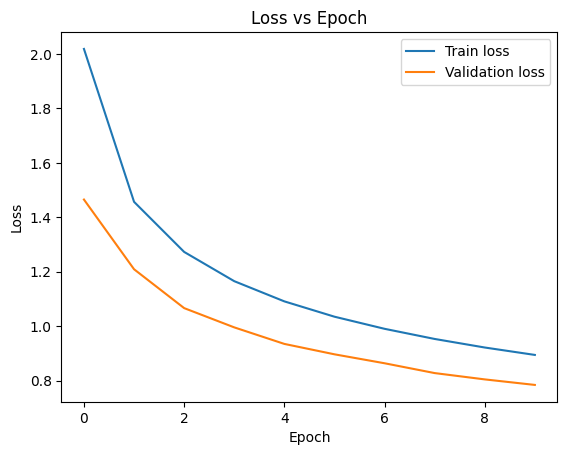

In [18]:
import matplotlib.pyplot as plt

plt.plot(train_loss_list, label = "Train loss")
plt.plot(validation_loss_list, label = "Validation loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [19]:
import torch

# 모델 저장
torch.save({
    'model_state_dict': model.state_dict(),
    'token2id': chem_tokenizer.vocab,
    'max_len': 128,  # res_len 포함
    'config': {
        'num_tokens': 767,
        'dim_model': 128,
        'num_heads': 4,
        'num_encoder_layers': 8,
        'num_decoder_layers': 8,
        'dropout_p': 0.1,
        "max_len": 128 
    }
}, 'model_checkpoint.pt')